# Задача 1 — Анализ трендов популярности технологий

## Описание
Анализ изменения популярности технологий на Stack Overflow за период 2024–2026 гг.
на основе количества вопросов с соответствующими тегами.

## Цель
Выявить растущие и падающие технологии, определить лидеров по количеству вопросов.

## Данные
- **Источник:** Stack Exchange Data Explorer (SEDE)
- **Период:** Июнь 2024 — Апрель 2026
- **Таблицы:** questions, tags, question_tags

In [1]:
import sys
sys.path.append('../')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from pathlib import Path

# Подключение к БД
ROOT = Path('..').resolve()
load_dotenv(ROOT / '.env')
engine = create_engine(os.getenv('DATABASE_URL'))

print('Подключение установлено')

Подключение установлено


## Загрузка данных

Загружаем количество вопросов по каждому тегу за каждый месяц из PostgreSQL.

In [2]:
query = """
    SELECT
        DATE_TRUNC('month', q.created_at) AS month,
        t.tag_name,
        COUNT(*) AS question_count
    FROM questions q
    JOIN question_tags qt ON qt.question_id = q.question_id
    JOIN tags t ON t.tag_id = qt.tag_id
    GROUP BY month, t.tag_name
    ORDER BY month, question_count DESC
"""
df = pd.read_sql(query, engine)
df["month"] = pd.to_datetime(df["month"])

print(f"Загружено строк: {len(df)}")
print(f"Уникальных тегов: {df['tag_name'].nunique()}")
print(f"Период: {df['month'].min().date()} — {df['month'].max().date()}")
df.head(10)

Загружено строк: 128400
Уникальных тегов: 26711
Период: 2024-06-01 — 2026-04-01


,month,tag_name,question_count
0,2024-06-01,python,1383
1,2024-06-01,javascript,707
2,2024-06-01,c#,530
3,2024-06-01,java,416
4,2024-06-01,reactjs,398
5,2024-06-01,android,368
6,2024-06-01,html,323
7,2024-06-01,r,322
8,2024-06-01,c++,317
9,2024-06-01,typescript,281


## Топ-10 технологий за весь период

In [3]:
top_tags = (
    df.groupby("tag_name")["question_count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_tags.columns = ["Технология", "Вопросов всего"]
top_tags

,Технология,Вопросов всего
0,python,20404
1,javascript,9791
2,c#,8936
3,java,8093
4,android,6772
5,c++,6599
6,reactjs,5125
7,r,4860
8,flutter,4650
9,typescript,4496


## График трендов популярности

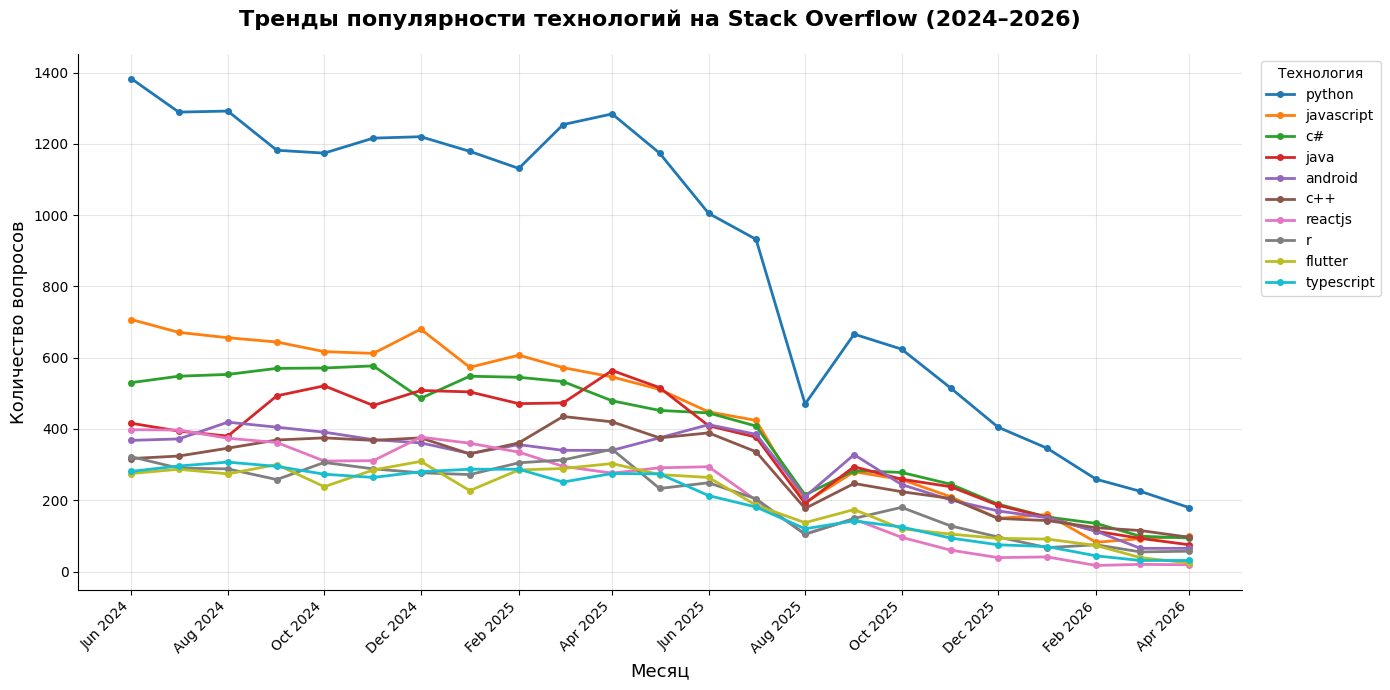

In [4]:
top_list = top_tags["Технология"].tolist()
filtered = df[df["tag_name"].isin(top_list)]
pivot = filtered.pivot_table(
    index="month", columns="tag_name", 
    values="question_count", fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 7))
colors = sns.color_palette("tab10", len(top_list))

for i, tag in enumerate(top_list):
    if tag in pivot.columns:
        ax.plot(pivot.index, pivot[tag], label=tag,
                linewidth=2, marker="o", markersize=4, color=colors[i])

ax.set_title("Тренды популярности технологий на Stack Overflow (2024–2026)",
             fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Месяц", fontsize=13)
ax.set_ylabel("Количество вопросов", fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha="right")
ax.legend(title="Технология", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

## Тепловая карта активности по технологиям

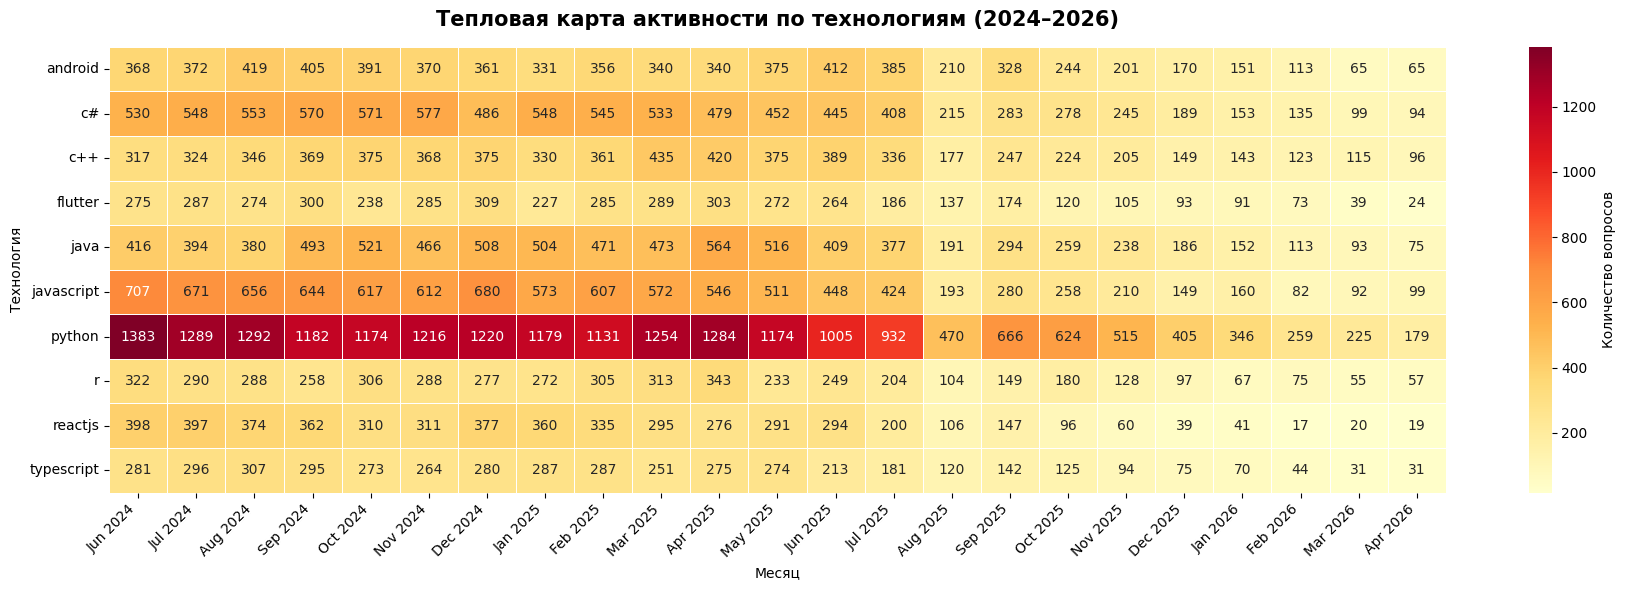

In [5]:
pivot_heat = filtered.pivot_table(
    index="tag_name", columns="month", 
    values="question_count", fill_value=0
)
pivot_heat.columns = pivot_heat.columns.strftime("%b %Y")

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    pivot_heat, cmap="YlOrRd", annot=True, fmt=".0f",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Количество вопросов"}
)
ax.set_title("Тепловая карта активности по технологиям (2024–2026)",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Месяц")
ax.set_ylabel("Технология")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Выводы

1. **Python** остаётся безусловным лидером на Stack Overflow с большим отрывом — 
в среднем в 2 раза больше вопросов чем у ближайшего конкурента (JavaScript).

2. **Общий тренд** — снижение активности по всем технологиям начиная с середины 2025 года, 
что совпадает с массовым распространением LLM-инструментов (ChatGPT, GitHub Copilot).

3. **Летний спад** — июль-август 2025 показывают минимальную активность, 
что характерно для сезонного поведения разработчиков.

4. **Стабильные технологии** — JavaScript, C#, Java держатся примерно на одном уровне 
относительно друг друга на протяжении всего периода.

5. **Растущие** — ReactJS появился в топ-10 после докачки полных данных.